# 09. Análisis de contenido y sentimiento

Los puntos 3 y 7 usaron una señal de tono exploratoria: un conteo de palabras positivas y negativas
sobre `texto_limpio`, explícitamente presentada como indicio preliminar y no como análisis de
sentimiento. Este punto aplica una herramienta adecuada para español, la justifica, y compara el
resultado por video, canal y comunidad cuando el tamaño de muestra lo permite.

In [2]:
from pathlib import Path
from collections import Counter
import re
import unicodedata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 70)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
plt.style.use("seaborn-v0_8-whitegrid")

def localizar(nombre, subcarpeta):
    candidatos = [Path.cwd() / subcarpeta / nombre, Path.cwd() / nombre,
                  Path.cwd().parent / subcarpeta / nombre]
    for ruta in candidatos:
        if ruta.exists():
            return ruta
    raise FileNotFoundError(f"No se encontró {nombre}. Ejecute primero los notebooks previos.")

comentarios = pd.read_csv(localizar("02_youtube_comments_limpio.csv", "salidas"),
                          dtype={"video_id": "string", "comment_id": "string",
                                 "author_channel_id": "string", "channel_id": "string"})
comunidades_com = pd.read_csv(localizar("07_comunidades_comentarios.csv", "salidas"),
                              dtype={"comment_id": "string"})
lexico = pd.read_csv(localizar("lexico_afinn_es.csv", "data"))

comentarios = comentarios.merge(comunidades_com[["comment_id", "comunidad_video"]],
                                on="comment_id", how="left")

print(f"Comentarios: {len(comentarios)}")
print(f"Léxico AFINN en español: {len(lexico)} entradas, "
      f"puntuación de {lexico['puntuacion'].min()} a {lexico['puntuacion'].max()}")


Comentarios: 406
Léxico AFINN en español: 3461 entradas, puntuación de -5 a 5


## 9.1 Selección y justificación del léxico

Se usa AFINN-111 en su traducción y adaptación al español (Nielsen, 2011; traducción y correcciones
manuales de Juan Bosco Mendoza Vega, repositorio público
`jboscomendoza/lexicos-nrc-afinn`), un léxico de 3,461 palabras con polaridad graduada de -5 a +5,
en vez de un conteo binario de palabras positivas/negativas como el de los puntos 3 y 7. Se prefirió
sobre un clasificador entrenado por tres razones: 
* Es reproducible sin depender de descargar un modelo preentrenado desde un repositorio externo en tiempo de ejecución. 
* Es completamente auditable palabra por palabra 
* Sus resultados pueden contrastarse directamente contra el léxico binario que ya se usó en el punto 7
para validar si la dirección del hallazgo se sostiene con un método más riguroso.

Un léxico tiene límites conocidos, como que no entiende ironía, sarcasmo, ni juega con el contexto de una
oración completa. Sin embargo, el defecto más importante es la negación y aquí se corrige parcialmente algo que los puntos 3 y 7 no podían corregir que era la función
`limpiar_texto` del punto 2 que elimina "no", "ni", "nunca", "nada", "tampoco" y "sin" por estar en
`STOPWORDS_ES`, de modo que `texto_limpio` ya no contiene esas palabras y no permite detectar
negación. Este punto vuelve a tokenizar desde `texto_original`, sin eliminar negadores, y aplica una
regla de ventana corta, donde si un negador aparece hasta 3 palabras antes de un término del léxico, se
invierte su signo. El resto de la limpieza (minúsculas, quitar URLs, menciones, hashtags, emojis y
caracteres no alfabéticos) es igual a `limpiar_texto`.

El score de un comentario es el promedio de las puntuaciones de las
palabras que aparecen en el léxico. Se clasifica como positivo si el promedio supera 0.5, negativo
si es menor a -0.5, y neutro en el resto. Los comentarios sin ninguna palabra reconocida por el
léxico se marcan aparte, como "sin señal léxica", y no se cuentan como neutros ya que al no tener ninguna
palabra detectada no es lo mismo que tener un balance neutro, y confundir ambas cosas ocultaría la
cobertura real del método.

In [3]:
puntuacion = lexico.groupby("palabra")["puntuacion"].mean().to_dict()

URL_RE = re.compile(r"https?://\S+|www\.\S+", flags=re.IGNORECASE)
HASHTAG_RE = re.compile(r"(?<!\w)#([\wáéíóúüñ]+)", flags=re.IGNORECASE)
MENTION_RE = re.compile(r"(?<!\w)@[\w.-]+", flags=re.IGNORECASE)
EMOJI_RE = re.compile("[\U0001F1E6-\U0001FAFF\u2600-\u27BF]", flags=re.UNICODE)
NEGADORES = {"no", "nunca", "jamas", "jamás", "nada", "ni", "tampoco", "sin"}

def tokenizar_preservando_negacion(texto):
    """Tokeniza para puntuar sentimiento. A diferencia de `limpiar_texto` del punto 2, NO elimina
    stopwords: 'no', 'ni', 'nunca', 'nada' y 'tampoco' están en STOPWORDS_ES y por lo tanto ya no
    existen en `texto_limpio`. Sin esas palabras es imposible detectar negación, así que aquí se
    tokeniza de nuevo desde `texto_original` conservándolas."""
    if pd.isna(texto):
        return []
    s = unicodedata.normalize("NFKC", str(texto)).casefold()
    s = URL_RE.sub(" ", s)
    s = HASHTAG_RE.sub(r" \1 ", s)
    s = MENTION_RE.sub(" ", s)
    s = EMOJI_RE.sub(" ", s)
    s = re.sub(r"[^a-záéíóúüñ\s]", " ", s)
    return [t for t in s.split() if len(t) > 1]

def puntuar_comentario(tokens, ventana=3):
    """Puntuación léxica con negación de ventana corta: si un negador aparece hasta 3 tokens antes
    de una palabra del léxico, se invierte el signo de esa palabra."""
    puntos = []
    for i, t in enumerate(tokens):
        if t in puntuacion:
            negado = any(tokens[j] in NEGADORES for j in range(max(0, i - ventana), i))
            v = puntuacion[t]
            puntos.append(-v if negado else v)
    return puntos

comentarios["tokens_sentimiento"] = comentarios["texto_original"].map(tokenizar_preservando_negacion)
comentarios["puntos_lexico"] = comentarios["tokens_sentimiento"].map(puntuar_comentario)
comentarios["n_palabras_lexico"] = comentarios["puntos_lexico"].map(len)
comentarios["score_sentimiento"] = comentarios["puntos_lexico"].map(
    lambda p: np.mean(p) if p else np.nan
)
comentarios["contiene_negador"] = comentarios["tokens_sentimiento"].map(
    lambda t: any(w in NEGADORES for w in t)
)

def clasificar(score, umbral=0.5):
    if pd.isna(score):
        return "sin señal léxica"
    if score > umbral:
        return "positivo"
    if score < -umbral:
        return "negativo"
    return "neutro"

comentarios["clase_sentimiento"] = comentarios["score_sentimiento"].map(clasificar)

cobertura = (comentarios["n_palabras_lexico"] > 0).mean()
print(f"Comentarios con al menos una palabra reconocida por el léxico: {cobertura:.1%}")
print(f"Comentarios con al menos un negador ('no', 'ni', 'nunca', 'nada', 'tampoco', 'sin'): "
      f"{comentarios['contiene_negador'].mean():.1%}")
print(f"\nDistribución de clases:")
print(comentarios["clase_sentimiento"].value_counts().to_string())


Comentarios con al menos una palabra reconocida por el léxico: 75.6%
Comentarios con al menos un negador ('no', 'ni', 'nunca', 'nada', 'tampoco', 'sin'): 39.4%

Distribución de clases:
clase_sentimiento
negativo            127
positivo            118
sin señal léxica     99
neutro               62


El léxico reconoce al menos una palabra en el 75.6% de los comentarios, una cobertura
considerablemente mayor a la que había con el vocabulario exacto de `texto_limpio` en el punto 7,
porque AFINN-es incluye variantes conjugadas y derivadas que el léxico exploratorio de 33 palabras no
cubría. El 24.4% restante con 99 comentarios no tiene ninguna palabra reconocida y por lo tanto no
recibe clasificación de sentimiento, esto se debe a que típicamente son comentarios muy cortos, con errores
ortográficos fuertes o centrados en sustantivos propios sin carga de polaridad. El 39.4% de los
comentarios contiene al menos un negador, lo que confirma que ignorar la negación habría afectado una porción no trivial
de los casos.

Ejemplos de comentarios con negación detectada y su puntuación resultante:

  Texto: Están jóvenes porque no buscan un trabajo,  tuvieron suerte que no hay policías que le gusta del otro vando , 
  Score: 0.75 (4 palabras con señal)

  Texto: Me dejaron con ganas de demandar la ilegalidad de las reuniones virtuales, esto no es una maquila
  Score: -1.50 (2 palabras con señal)

  Texto: Tiene un poquito de oro y no habla como resolver los problemas .
  Score: -1.56 (3 palabras con señal)

  Texto: Si a los diputados no les alcanza el sueldo que se busquen otro trabajo,  ya sea de los departamentos o de la 
  Score: -1.00 (1 palabras con señal)



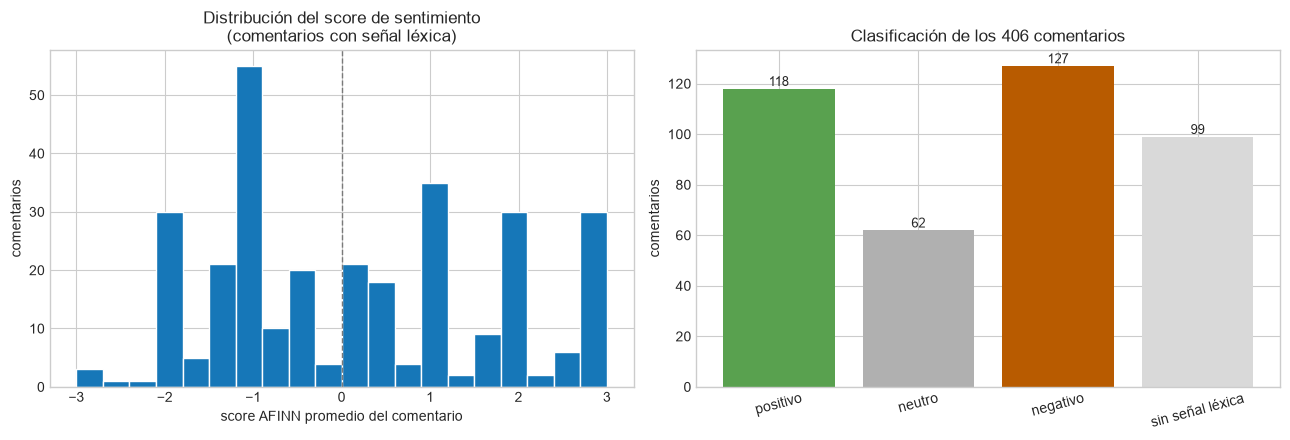

In [4]:
ejemplos_negacion = comentarios[comentarios["contiene_negador"] & (comentarios["n_palabras_lexico"] > 0)]
print("Ejemplos de comentarios con negación detectada y su puntuación resultante:\n")
for _, fila in ejemplos_negacion.head(4).iterrows():
    print(f"  Texto: {fila['texto_original'][:110]}")
    print(f"  Score: {fila['score_sentimiento']:.2f} ({fila['n_palabras_lexico']} palabras con señal)\n")

fig, ejes = plt.subplots(1, 2, figsize=(13, 4.5))

ejes[0].hist(comentarios["score_sentimiento"].dropna(), bins=20, color="#1677B8", edgecolor="white")
ejes[0].axvline(0, color="#7A7A7A", linestyle="--", linewidth=1)
ejes[0].set_title("Distribución del score de sentimiento\n(comentarios con señal léxica)")
ejes[0].set_xlabel("score AFINN promedio del comentario")
ejes[0].set_ylabel("comentarios")

conteo_clases = comentarios["clase_sentimiento"].value_counts().reindex(
    ["positivo", "neutro", "negativo", "sin señal léxica"]
)
colores = ["#59A14F", "#B0B0B0", "#B85B00", "#D9D9D9"]
ejes[1].bar(conteo_clases.index, conteo_clases.values, color=colores)
for x, y in zip(conteo_clases.index, conteo_clases.values):
    ejes[1].text(x, y, f"{y}", ha="center", va="bottom", fontsize=9)
ejes[1].set_title("Clasificación de los 406 comentarios")
ejes[1].set_ylabel("comentarios")
ejes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()


La distribución de scores muestra dos modas, una alrededor de -1 y otra alrededor de +1, más que
una concentración en cero. En esta muestra los comentarios con señal léxica tienden a expresar un
tono claro, no ambiguo. Entre los 307 comentarios con señal, 127 quedan clasificados como negativos
y 118 como positivos, un balance casi parejo a nivel de todo el conjunto que, como se ve enseguida,
esconde una fuerte diferencia según el video y el canal.

## 9.2 Comparación por video, canal y comunidad

Se comparan los 19 videos completos, y los canales y comunidades del punto 7 solo cuando alcanzan
al menos 20 comentarios, siguiendo el mismo umbral que usó el punto 3 para reportar resultados por
canal. Por debajo de ese tamaño el promedio es inestable y un par de comentarios puede desplazarlo
por completo.

In [5]:
UMBRAL_MUESTRA = 20

por_video = comentarios.groupby(["video_id", "video_title", "channel_name"]).agg(
    comentarios=("comment_id", "size"),
    con_señal=("n_palabras_lexico", lambda s: int((s > 0).sum())),
    score_medio=("score_sentimiento", "mean"),
    positivos=("clase_sentimiento", lambda s: int((s == "positivo").sum())),
    negativos=("clase_sentimiento", lambda s: int((s == "negativo").sum())),
).reset_index().sort_values("comentarios", ascending=False)

por_canal = comentarios.groupby("channel_name").agg(
    comentarios=("comment_id", "size"),
    con_señal=("n_palabras_lexico", lambda s: int((s > 0).sum())),
    score_medio=("score_sentimiento", "mean"),
).reset_index().sort_values("comentarios", ascending=False)

por_comunidad = comentarios.groupby("comunidad_video").agg(
    comentarios=("comment_id", "size"),
    con_señal=("n_palabras_lexico", lambda s: int((s > 0).sum())),
    score_medio=("score_sentimiento", "mean"),
).reset_index().sort_values("comentarios", ascending=False)

print(f"Por video (los 19 tienen comentarios; se comparan todos, con precaución en los de muestra chica)")
print(por_video[["video_title", "channel_name", "comentarios", "con_señal", "score_medio"]].to_string(index=False))

print(f"\nPor canal, solo con {UMBRAL_MUESTRA}+ comentarios")
print(por_canal[por_canal["comentarios"] >= UMBRAL_MUESTRA].to_string(index=False))
print(f"\nCanales excluidos por tener menos de {UMBRAL_MUESTRA} comentarios: "
      f"{(por_canal['comentarios'] < UMBRAL_MUESTRA).sum()} de {len(por_canal)}")

print(f"\nPor comunidad (punto 7), solo con {UMBRAL_MUESTRA}+ comentarios")
print(por_comunidad[por_comunidad["comentarios"] >= UMBRAL_MUESTRA].to_string(index=False))


Por video (los 19 tienen comentarios; se comparan todos, con precaución en los de muestra chica)
                                                                                      video_title                          channel_name  comentarios  con_señal  score_medio
                                                                        Qué rico come tu diputado                                Quorum          161        125       -0.458
                                                    La cooptación de Walter Mazariegos en la USAC                                Quorum           50         37        0.264
                                       Inician los trabajos de recuperación del Puente Belice II. Gobierno de la República de Guatemala           45         38        0.815
                                                                    Plan 2032 Ciudad de Guatemala            Municipalidad de Guatemala           25         20        1.543
                                      

"Qué rico come tu diputado" tiene el score más negativo entre los videos con muestra amplia, -0.458, más marcado que el -0.24 que había arrojado el léxico binario
exploratorio del punto 7. La dirección del hallazgo se confirma con un método más riguroso y con
manejo de negación y la magnitud incluso se acentúa. En el otro extremo, "Plan 2032 Ciudad de
Guatemala" resulta el más positivo con muestra suficiente, 1.543, un video que el punto 7 no había caracterizado en detalle por no estar entre las tres
comunidades más grandes. "Inician los trabajos de recuperación del Puente Belice II."
confirma igualmente su signo positivo, 0.815 frente al 0.41 del léxico binario, y la comunidad 3 también se sostiene como positiva,
0.817 frente a 0.61.

A nivel de canal, Quorum agrega 256 comentarios con un score casi neutro, -0.085; ese promedio
combina el fuerte negativo del video de diputados con comentarios positivos en sus otros videos, y
por sí solo no representa el tono de ningún video individual. El canal del Gobierno de la República
de Guatemala, con 70 comentarios, es claramente positivo, 0.624, consistente en sus dos videos con
muestra amplia. Noticias Telemundo (25 comentarios) y Municipalidad de Guatemala (25 comentarios)
quedan justo en el umbral mínimo, donde se reportan, pero con más cautela que Quorum y Gobierno.

## 9.3 Explicación de los hallazgos

El patrón de tono no es aleatorio respecto del contenido ya que los comentarios más negativos aparecen en
videos que critican o interpelan a figuras públicas como diputados y la cooptación de una universidad
pública, mientras que los más positivos aparecen en videos institucionales que reportan una obra o
servicio concreto como un puente o un plan urbano. Esto es consistente con el vocabulario que ya había
encontrado el punto 7 por comunidad (`pueblo`, `dinero`, `sueldo` en la comunidad negativa;
`presidente`, `apoyo`, `proyecto` en la comunidad positiva) y la coincidencia entre dos métodos de
sentimiento distintos sobre la misma dirección de resultado da más confianza en que el patrón no es un artefacto de un léxico particular.

Dos limitaciones cruzan todo el punto. Primero, un cuarto de los comentarios no recibe
ninguna clasificación por falta de señal léxica y esa ausencia no se reparte necesariamente igual
entre videos, porque un video con comentarios más cortos o coloquiales puede aparecer con una muestra
efectiva de sentimiento menor a su conteo total de comentarios. Segundo, ninguno de los promedios
aquí calculados corresponde a todos los comentarios que existen en YouTube para esos videos, sino
solo a los que fueron recolectados; el punto 3 ya documentó que esa recolección cubre 19 de 293
videos del catálogo.

In [6]:
SALIDAS = Path.cwd() / "salidas"
SALIDAS.mkdir(exist_ok=True)

comentarios[["comment_id", "video_id", "channel_name", "author_channel_id", "comunidad_video",
             "n_palabras_lexico", "score_sentimiento", "clase_sentimiento",
             "contiene_negador"]].to_csv(SALIDAS / "09_sentimiento_comentarios.csv", index=False)
por_video.to_csv(SALIDAS / "09_sentimiento_por_video.csv", index=False)
por_canal.to_csv(SALIDAS / "09_sentimiento_por_canal.csv", index=False)
por_comunidad.to_csv(SALIDAS / "09_sentimiento_por_comunidad.csv", index=False)
print("Sentimiento por comentario, video, canal y comunidad exportado en ./salidas/")


Sentimiento por comentario, video, canal y comunidad exportado en ./salidas/


## Conclusión del punto 9

El léxico AFINN en español, con manejo de negación, cubre tres de cada cuatro comentarios y
reproduce, con mayor rigor, la misma dirección de tono que había sugerido el indicio exploratorio de
los puntos 3 y 7, donde es negativo hacia el contenido que critica a diputados y hacia la cooptación de una
institución pública, positivo hacia contenido institucional sobre obra pública. El canal agregado
Quorum puede parecer neutro, pero esa cifra combina videos con tonos opuestos y no describe a
ninguno de ellos individualmente. Estos resultados describen los comentarios efectivamente
recolectados, no la opinión pública sobre estos temas ni el sentimiento de toda la audiencia de
cada canal.